_________________________________________可视化部分（初初版很潦草）


# 2. Visualization of Collected Data

In this chapter, we conduct a comprehensive visualization of the collected data. Our goal is to intuitively understand the distribution of the money and identify potential patterns that will guide our reverse engineering process in the next chapter.

The dataset consists of **100 rounds** of Red Envelope grabbing in a **3-person group** with a fixed total amount of **5.00 RMB**.

## 2.1 Preliminary Visualization: Global Distribution

First, we examine the **global distribution** of the grabbed amounts. By pooling all the data points , we can check its overall distribution.

In [2]:
!pip install pandas numpy matplotlib seaborn scipy

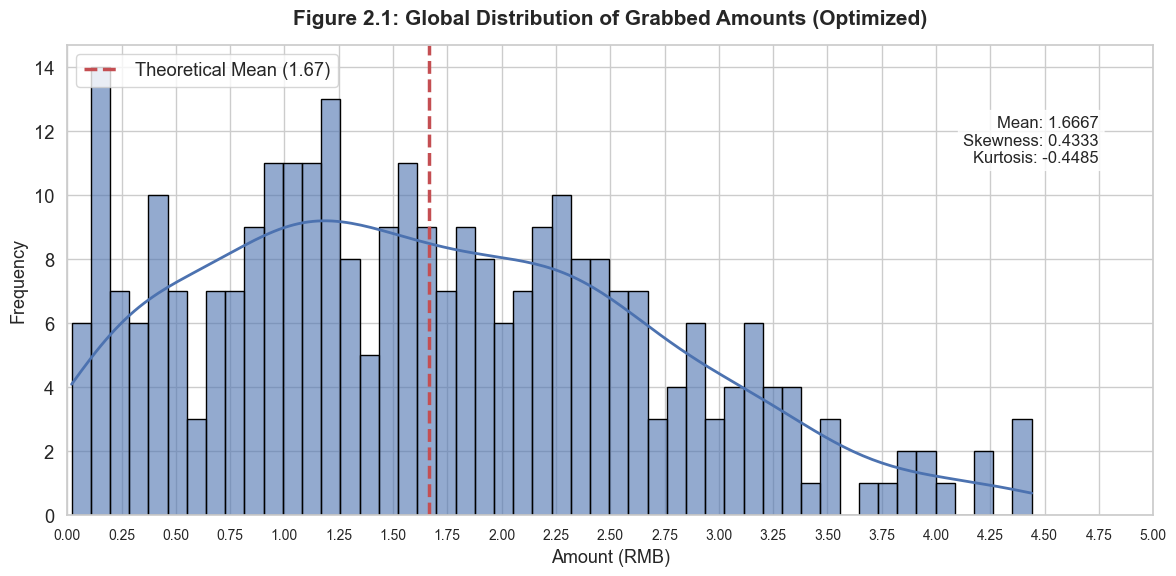

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 1. Set plotting style
sns.set_theme(style="whitegrid", font_scale=1.2) 
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False 

# 2. Data Loading and Preprocessing 
df = pd.read_csv('data/red_packet_data.csv') 
grab_amounts = df[['first', 'second', 'third']].values.flatten()

# 3. Core Visualization Optimization
plt.figure(figsize=(12, 6)) 
sns.histplot(grab_amounts, bins=50, kde=True, 
             color='#4c72b0', edgecolor='black', alpha=0.6, line_kws={'linewidth': 2})

# Add theoretical mean reference line
plt.axvline(x=5/3, color='#c44e52', linestyle='--', linewidth=2.5, label=f'Theoretical Mean ({5/3:.2f})')

plt.xlim(0, 5)
plt.xticks(np.arange(0, 5.25, 0.25), fontsize=10, rotation=0) 
plt.title('Figure 2.1: Global Distribution of Grabbed Amounts (Optimized)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Amount (RMB)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Statistical Annotation 
stats_text = (f"Mean: {np.mean(grab_amounts):.4f}\n"
              f"Skewness: {skew(grab_amounts):.4f}\n"
              f"Kurtosis: {kurtosis(grab_amounts):.4f}")
plt.gca().text(0.95, 0.85, stats_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

### Analysis of Global Distribution

From Figure 2.1 and the calculated statistics, we observe distinct characteristics that deviate from standard distributions:

1.  **Irregular and Skewed Shape:** The visualization does not exhibit the bell curve of a Normal Distribution, nor does it form the perfect rectangle of a Uniform Distribution. Instead, we observe a **right-skewed** shape extending towards $4.5$ RMB. This indicates that while most amounts cluster between $0.5$ and $2.5$, there is a "long tail" probability of grabbing significantly large amounts.
2.  **Mean Consistency:** The empirical sample mean is **1.6667**, which is an exact match to the theoretical expectation ($5.00 / 3 \approx 1.67$ RMB). This serves as a strong validation of the "Fairness" assumption: despite the randomness, the total money is conserved and average returns are unbiased.
3.  **Statistical Moments Insight:**
    * **Kurtosis (-0.4485):** This negative value confirms the distribution is *platykurtic* (flatter than a Normal distribution, which has kurtosis 0). However, it is not low enough to suggest a pure Uniform distribution (which typically has a kurtosis of -1.2).
    * **Skewness (0.4333):** The positive skewness confirms the visual observation of the right tail.
    * **Interpretation:** The fact that the statistics fall somewhere "in between" standard distributions strongly suggests that Figure 2.1 is actually a **Mixture Distribution**. Aggregating the data likely conflates three distinct underlying mechanisms (for the 1st, 2nd, and 3rd person).

The global view is informative for verifying overall fairness but obscures the specific algorithm. The "mixed" statistical signals compel us to decompose the data by **sequence** and **user identity** to reveal the true underlying rules.

## 2.2 Further Visualization: The Impact of Sequence

To explore the mechanism deeper, we separate the data based on the **order of grabbing** (1st, 2nd, and 3rd). This is critical because the money available to the current person depends on how much previous people have taken.

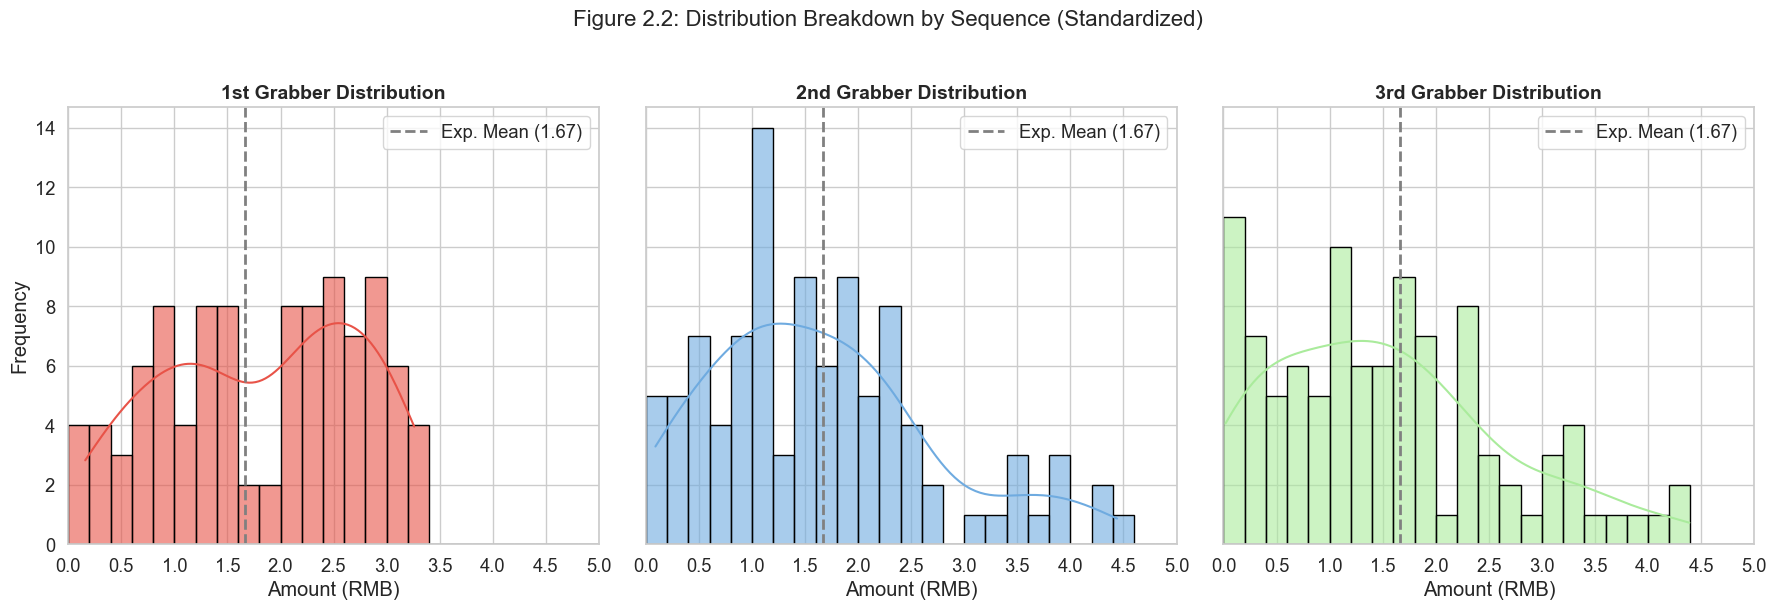

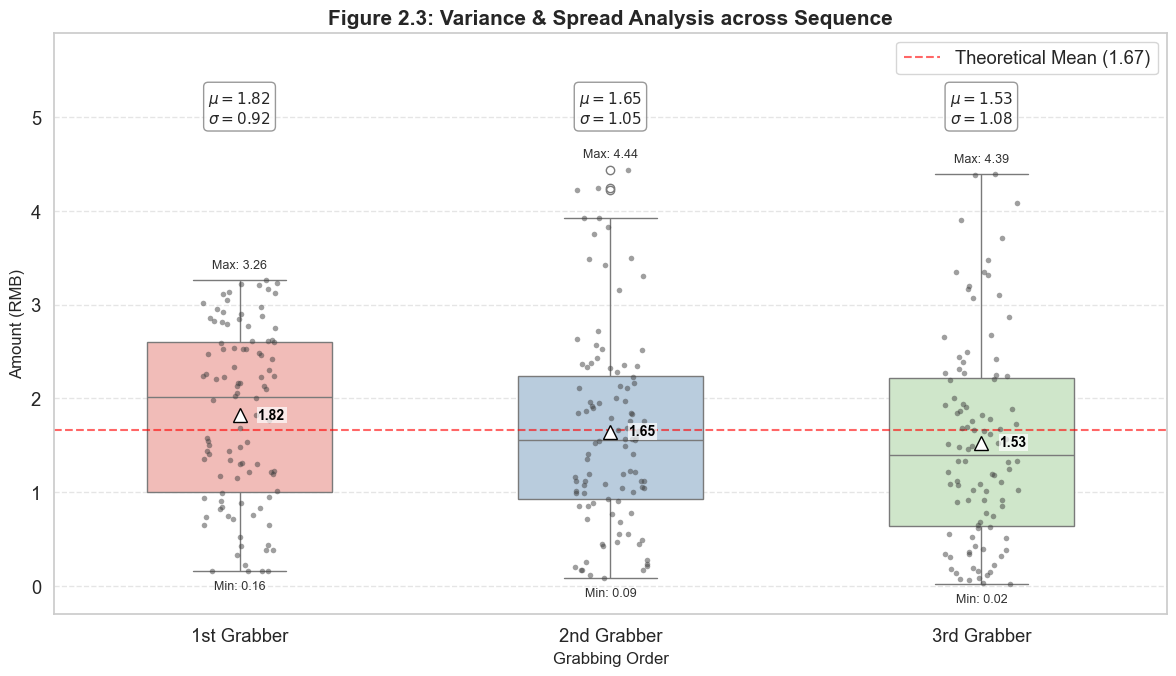

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global styling
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Define consistent color palette for all figures
custom_colors = ['#E85348', '#6FABE0', '#AAEB9C']

# ==========================================
# Figure 2.2: Standardized Histograms
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=False) 

labels = ['1st Grabber', '2nd Grabber', '3rd Grabber']
columns = ['first', 'second', 'third']

for i, col in enumerate(columns):
    # Plot histogram with fixed bin range (0-5) for consistency
    sns.histplot(df[col], ax=axes[i], 
                 bins=25, binrange=(0, 5), 
                 kde=True, 
                 color=custom_colors[i], edgecolor='black', alpha=0.6)
    
    # Add theoretical mean line
    axes[i].axvline(5/3, color='gray', linestyle='--', linewidth=2, label='Exp. Mean (1.67)')
    
    # Formatting axes
    axes[i].set_xlim(0, 5)
    axes[i].set_xticks(np.arange(0, 5.5, 0.5))
    axes[i].set_title(f'{labels[i]} Distribution', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Amount (RMB)')
    
    if i == 0:
        axes[i].set_ylabel('Frequency')
    
    axes[i].legend(loc='upper right', frameon=True)

plt.suptitle('Figure 2.2: Distribution Breakdown by Sequence (Standardized)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


# ==========================================
# Figure 2.3: Detailed Boxplot Statistics
# ==========================================
plt.figure(figsize=(12, 7))

plot_data = df[['first', 'second', 'third']]

# 1. Boxplot with consistent colors
ax = sns.boxplot(data=plot_data, palette="Pastel1", width=0.5,
                 showmeans=True,
                 meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

# 2. Overlay stripplot for data density
sns.stripplot(data=plot_data, color=".25", size=4, alpha=0.5, jitter=True)

# 3. Theoretical mean reference line
plt.axhline(5/3, color='red', linestyle='--', alpha=0.6, linewidth=1.5, label='Theoretical Mean (1.67)')

# 4. Add statistical annotations for each column
for i, col in enumerate(plot_data.columns):
    col_data = plot_data[col]
    
    # Calculate statistics
    mean_val = col_data.mean()
    max_val = col_data.max()
    min_val = col_data.min()
    std_val = col_data.std()
    
    # A. Annotate Mean (next to the triangle marker)
    ax.text(i + 0.05, mean_val, f'{mean_val:.2f}', 
            ha='left', va='center', color='black', fontweight='bold', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    
    # B. Annotate Max (above upper whisker)
    ax.text(i, max_val + 0.1, f'Max: {max_val:.2f}', 
            ha='center', va='bottom', fontsize=9, color='#333333')
    
    # C. Annotate Min (below lower whisker)
    ax.text(i, min_val - 0.1, f'Min: {min_val:.2f}', 
            ha='center', va='top', fontsize=9, color='#333333')

    # D. Annotate Std Dev & Mean (Top information box)
    info_text = f"$\\mu={mean_val:.2f}$\n$\\sigma={std_val:.2f}$"
    ax.text(i, 5.3, info_text, 
            ha='center', va='top', fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Formatting
plt.ylim(-0.3, 5.9) # Extend y-limit for top annotations
plt.title('Figure 2.3: Variance & Spread Analysis across Sequence', fontsize=15, fontweight='bold')
plt.xlabel('Grabbing Order', fontsize=12)
plt.ylabel('Amount (RMB)', fontsize=12)
plt.xticks([0, 1, 2], ['1st Grabber', '2nd Grabber', '3rd Grabber'])
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Analysis and Insight for Modeling

Decomposing the data by sequence reveals critical patterns that are obscured in the global view. Based on **Figure 2.2** and **Figure 2.3**, we draw the following empirical conclusions:

#### 1. The "Bounded" Nature and Specific Shape of the First Grabber
Observing the **1st Grabber** (Green plot in Fig 2.2), we notice distinct morphological features:

* **Distribution Shape (Bimodal Structure):** The empirical data exhibits a **bimodal-like structure**. There is a noticeable "valley" around the theoretical mean ($1.67$ RMB), flanked by two local peaks on either side (approximately at $1.0$ and $2.5$). 
* **The "Hard" Upper Limit:** The data is strictly confined, where maximum observed value is approximately **3.33 RMB**, twice the expected value $1.67$. We can draw a preliminary conclusion that the **1st person** follows a bounded distribution $X_1 \in [0, 2E]$.

#### 2. Variance Expansion and Skewed Deformation
**Figure 2.2 (Red & Purple plots)** highlights how the distribution deforms for subsequent players:

* **Left-Shifted Peak with Right Tail:** Unlike the first person, the **2nd and 3rd grabbers** show a clear **unimodal distribution** that is distinct from a Normal curve.
    * The peaks (modes) are shifted to the **left** of the mean line ($< 1.67$), indicating a higher probability of receiving smaller amounts.
    * Crucially, there is a significant **long tail to the right**, extending towards $4.5$ RMB.
* **Risk Profile:** This "Left-Peak, Right-Tail" shape confirms that while most outcomes are small (below average), the volatility allows for rare, extremely high payouts, which the 1st grabber can hardly achieve.

#### 3. Insights from Variance & Spread Analysis (Figure 2.3)
Complementing the histogram analysis, the boxplot in **Figure 2.3** provides a direct comparison of central tendency and dispersion. We observe three distinct trends that characterize the sequential allocation mechanism:

* **Range Expansion vs. IQR Stability (The Nuance of Risk):**
    * **Range:** The **Range** expands dramatically. The 1st Grabber's outcomes are strictly bounded within $[0, 3.33]$, whereas the 3rd Grabber's outcomes explode to cover nearly the entire sample space ($0$ to $4.5$). This confirms that the latter you grab the packet, you absorb the more extreme uncertainty (tail risk).
    * **IQR:** Interestingly, the **IQR** (Interquartile Range) does not increase linearly. In fact, the 1st Grabber's box is relatively tall, reflecting a  distribution where data is widely and uniformly spread. The 2nd Grabber's box is located lower and slightly smaller, while the 3rd Grabber's box is the lowest and comparable in height with the 1st. This implies that while the **tail risk** (Range) is huge for the last person, the **core outcomes** (the middle 50%) are actually compressed into a lower value range due to the "right-skewed" nature of the distribution.

* **Decreasing Sample Means:**
    * Although the theoretical expectation is identical ($1.67$), our specific sample ($N=100$) shows a subtle downward trend in the empirical means (indicated by the white triangles).
    * The **1st Grabber's** mean is slightly *above* the red dashed line, while the **3rd Grabber's** mean falls slightly *below* it.

* **Median vs. Mean Divergence:**
    * A critical observation is the behavior of the **Median** (the solid horizontal line inside the box).
    * While the Means (triangles) stay relatively close to the theoretical line ($1.67$), the **Medians drop sharply** (from $\approx 2.0$ for the 1st person to $\approx 1.4$ for the 3rd).
    * **Interpretation:** This indicates that for later grabbers, the "typical" outcome is actually worse (lower median). However, their Mean is pulled back up by the rare "long tail" of high-value packets (the dots near $4.0+$ RMB). This perfectly illustrates the **"High Variance, Low Median"** nature of the later positions.


## 2.3 Further Visualization: Member-Specific Analysis

While Section 2.2 analyzed the impact of the *sequence*, our following analysis focuses on the **participants** themselves. We tracked the amounts received by three specific members: **Member 1 (cyb)**, **Member 2 (dlp)**, and **Member 3 (str)**.

The objective here is to verify the **fairness** of the mechanism across different users. Theoretically and intuitively, if the starting order is randomized among the group members, everyone's long-term average return should converge to the same expected value ($1.67$ RMB), regardless of the complex underlying algorithm. This step serves as a robustness check to see whether an "unlucky account" bias exists in our dataset.

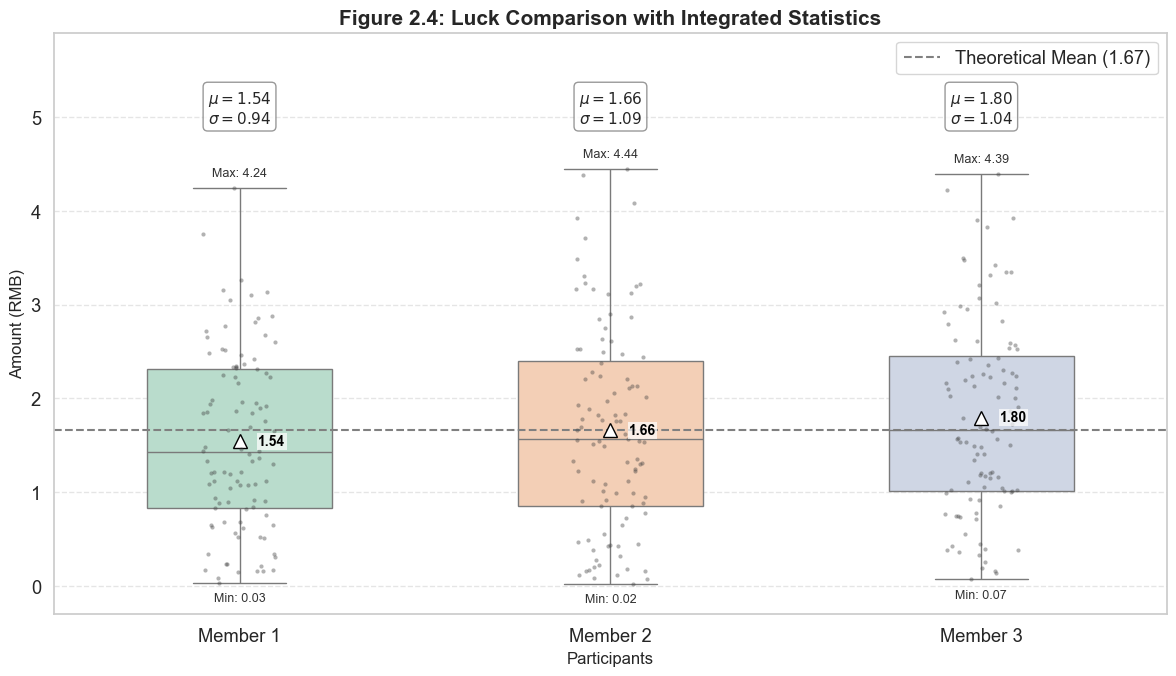

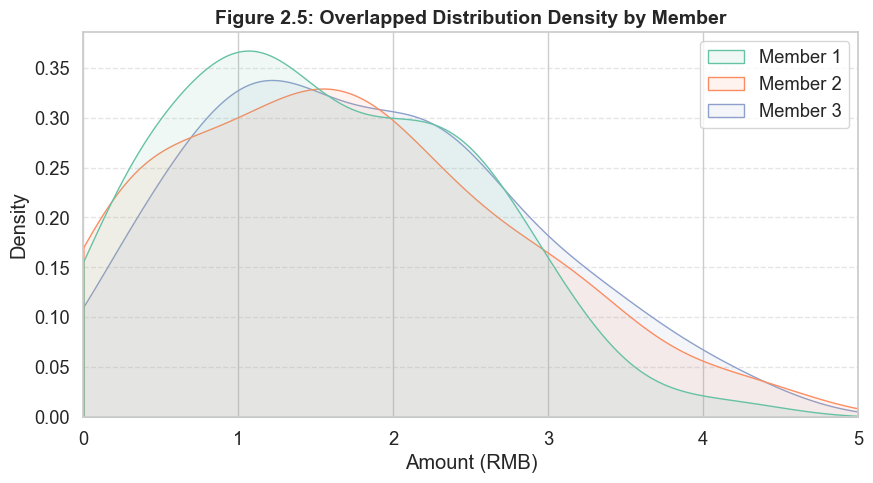

In [33]:
member_map = {'cyb': 'Member 1', 'dlp': 'Member 2', 'str': 'Member 3'}
df_members = df[['cyb', 'dlp', 'str']].rename(columns=member_map)

# ==========================================
# Figure 2.4: Boxplot with Integrated Statistical Annotations
# ==========================================
plt.figure(figsize=(12, 7))

# 1. Draw base plots
ax = sns.boxplot(data=df_members, palette="Pastel2", width=0.5,
                 showmeans=True,
                 meanprops={"marker":"^", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
# stripplot: Overlay scatter points
sns.stripplot(data=df_members, color=".25", size=3, alpha=0.4, jitter=True)
plt.axhline(5/3, color='gray', linestyle='--', linewidth=1.5, label='Theoretical Mean (1.67)')

# 2. Iterate through columns to add numerical annotations
for i, col in enumerate(df_members.columns):
    col_data = df_members[col]
    
    mean_val = col_data.mean()
    max_val = col_data.max()
    min_val = col_data.min()
    std_val = col_data.std()
    
    # A. Annotate Mean (next to the triangle marker)
    # Use formatted string for precision
    ax.text(i + 0.05, mean_val, f'{mean_val:.2f}', 
            ha='left', va='center', color='black', fontweight='bold', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))
    
    # B. Annotate Max (above the upper whisker)
    ax.text(i, max_val + 0.1, f'Max: {max_val:.2f}', 
            ha='center', va='bottom', fontsize=9, color='#333333')
    
    # C. Annotate Min (below the lower whisker)
    ax.text(i, min_val - 0.1, f'Min: {min_val:.2f}', 
            ha='center', va='top', fontsize=9, color='#333333')

    # D. Annotate Std Dev (as a text block at the top)
    # Set y-coordinate high enough to avoid overlapping with data points
    info_text = f"$\\mu={mean_val:.2f}$\n$\\sigma={std_val:.2f}$"
    ax.text(i, 5.3, info_text,  # Fixed position at y=5.3
            ha='center', va='top', fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.ylim(-0.3, 5.9)
plt.title('Figure 2.4: Luck Comparison with Integrated Statistics', fontsize=15, fontweight='bold')
plt.ylabel('Amount (RMB)', fontsize=12)
plt.xlabel('Participants', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Figure 2.5
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_members, fill=True, alpha=0.1, palette="Set2", common_norm=False, clip=(0, 5))
plt.title('Figure 2.5: Overlapped Distribution Density by Member', fontsize=14, fontweight='bold')
plt.xlabel('Amount (RMB)')
plt.xlim(0, 5)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Analysis of Member Distributions

Figures 2.4 and 2.5 provide a detailed breakdown of outcomes by participant identity. Unlike the theoretical expectation of perfect equality, our empirical data ($N=100$) reveals noticeable fluctuations in "luck":

1.  **Empirical Deviations in Mean Returns (Fig 2.4):**
    * **Observation:** While the theoretical mean is fixed at **1.67 RMB**, the actual average returns varied among members.
        * **Member 1** was the "unluckiest," with a mean of $\mu \approx 1.54$ RMB (below expectation).
        * **Member 2** was the closest to the theoretical value ($\mu \approx 1.66$ RMB).
        * **Member 3** was the "luckiest," achieving a mean of $\mu \approx 1.80$ RMB (above expectation).
    * **Interpretation:** Observing the scatter points (dots), Member 3 captured a higher density of high-value packets (dots near 4.0 RMB), whereas Member 1's high-value dots are sparser. In a limited sample size of 100 rounds, a few "lucky" large packets can significantly skew the mean.

2.  **Consistency in Range and Volatility:**
    * **Range:** Despite the difference in means, the **potential range** for all members is nearly identical. Everyone had a minimum near $0.02-0.07$ and a maximum near $4.2-4.4$. This confirms that no user is "capped" at a lower limit or "boosted" to a higher limit than others.
    * **Volatility ($\sigma$):** Member 2 exhibited the highest volatility ($\sigma \approx 1.09$), while Member 1 was the most stable ($\sigma \approx 0.94$). This suggests Member 1's payouts were more concentrated around small-to-medium values.

3.  **Distributional Similarity (Fig 2.5):**
    * The Kernel Density Estimation (KDE) curves show that while the *positions* of the peaks shift slightly (consistent with the mean differences), the **functional shape** of the distributions is identical.
    * All three curves are mostly **unimodal and right-skewed**, peaking around 1.0 - 1.5 RMB with a long tail extending to the right.
    * **Conclusion:** The overlap suggests that the *underlying probability density function (PDF)* is likely the same for all users. The observed shifts are attributable to **sample variance** rather than distinct algorithmic rules for specific user IDs.



## 2.4 Brief Conclusion of Exploratory Data Analysis and Visualization

Through the comprehensive visualizations in this chapter, we have established the following empirical facts to guide our reverse engineering:

1.  **Global View:** The data follows a non-normal, right-skewed distribution.
2.  **Sequence Impact:** The **grabbing order** is the primary variable. The 1st grabber shows a bounded distribution ($X \in [0, \approx 2E]$), while subsequent grabbers face increasing variance and skewness.
3.  **User Impact:** The mechanism appears **identity-agnostic**. Although our sample showed Member 3 earning more than Member 1, the identical distribution shapes and ranges suggest this is due to random chance within 100 trials, ensuring long-term fairness.

These findings strongly point towards a dynamic allocation strategy based on remaining amounts. 

Based on the visual evidence in Section 2.2, specifically the **Uniform-like distribution** of the first grabber with an upper bound close to **2x the average**—we hypothesize that the underlying algorithm is the **"Double Mean Method"** (or Double Expectation). 
* **Theoretical Connection:** Note that $3.33 \approx 2 \times 1.67$. This "hard boundary" at exactly twice the expected mean is a stronger indicator of the underlying mechanism (Double Mean) than the fluctuating shape itself.


#### 3. Hypothesis Formulation
The empirical data explicitly contradicts a static distribution model. Instead, it supports a dynamic model where:
1.  The **1st person** follows a bounded distribution $X_1 \in [0, 2E]$. It is not likely to be a coincidence, and the boundary condition strongly hints at the $2E$ constraint.
2.  Subsequent users follow a skewed distribution that depends on the *remaining* money, naturally forming a right-tailed shape.

Therefore, we formally propose the **Double Mean Model** as the underlying algorithm. In **Chapter 3**, we will simulate this model to see if a Uniform generator ($U(0, 2E)$) naturally produces such "bimodal-looking" fluctuations under small sample sizes ($N=100$), or if the intrinsic mechanism is more complex.
注意！！！我觉得这里的衔接其实不应该出现double mean的分布结果，应该是下一章节做了各种比较之后再得出结果，所以这个cell正文里应该删掉。这里保留属于抛砖引玉一下，我的Gemini教我这里的数学原理。